In [81]:
import os
import numpy as np
from scipy.signal import welch, butter, sosfiltfilt, freqs
import matplotlib.pyplot as plt
#from scipy.io.wavfile import write
#from scipy.signal import periodogram, spectrogram, oaconvolve
from asammdf import MDF

import librosa

In [83]:
import sys

sys.path.append("../configs/")

import warnings
warnings.filterwarnings("ignore")

import scipy.signal as sg
import scipy.signal as sn

import numpy as np
import emd
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq

import pywt

In [85]:
import pandas as pd

In [131]:
cols_to_use = ['Time', 'X1HB', 'Z1GD', 'Y1AvAr', 'X2HB', 'Z2GD', 'Y2AvAr']
df = pd.read_csv('/Volumes/Seagate Drive/pdi/nouvelle_tournee/24090902si11_ABA.csv', usecols=cols_to_use)

In [132]:
df['Time'].iloc[0]

'15:46:26.2600 09/09/2024'

In [133]:
df['Time'].iloc[-1]

'16:29:41.5293 09/09/2024'

In [137]:
df.head()

,Time,X1HB,Z1GD,Y1AvAr,X2HB,Z2GD,Y2AvAr
0,15:46:26.2600 09/09/2024,-0.080576,0.003468,-0.006565,0.076327,0.000836,0.005606
1,15:46:26.2601 09/09/2024,-0.086003,0.002646,-0.002453,0.077643,0.002317,0.003797
2,15:46:26.2602 09/09/2024,-0.079095,0.004455,-0.007880,0.084715,0.002317,0.003797
3,15:46:26.2603 09/09/2024,-0.085345,0.003961,-0.008045,0.082742,0.001823,0.002810
4,15:46:26.2604 09/09/2024,-0.089292,0.003797,-0.000808,0.084386,0.001165,0.000343


<h3>Regroupe les lignes concernant les données d’accélération du fichier par paquets de 10 lignes pour en calculer la moyenne et utilise la médiane des timestamps pour représenter le temps de chaque groupe</h3>

In [109]:
# Convertir 'Time' en datetime et en secondes écoulées depuis le début
df['Time'] = pd.to_datetime(df['Time'], format='%H:%M:%S.%f %d/%m/%Y')
#df['Time'] = df['Time'].dt.total_seconds()
df['Time'] = (df['Time'] - df['Time'].iloc[0]).dt.total_seconds()

# Déterminer la taille de regroupement
window_size = 10
num_rows = len(df)

if num_rows < window_size:
    raise ValueError("Le dataset est trop petit pour être groupé par 10.")

# Créer un index de regroupement
df['group'] = np.arange(num_rows) // window_size

# Moyenne des valeurs par groupes de 10
df_reduced = df.groupby('group').mean().reset_index()

# Utiliser la médiane du groupe
df_reduced['Time'] = df.groupby('group')['Time'].median().values

# Supprimer la colonne de groupement
df_reduced = df_reduced.drop(columns=['group'])

print("Réduction terminée. Nouvelle taille du dataset :", df_reduced.shape)


15:46:26.2600 09/09/2024
Réduction terminée. Nouvelle taille du dataset : (2595342, 7)


<h1>Accélération en fonction du temps</h1>

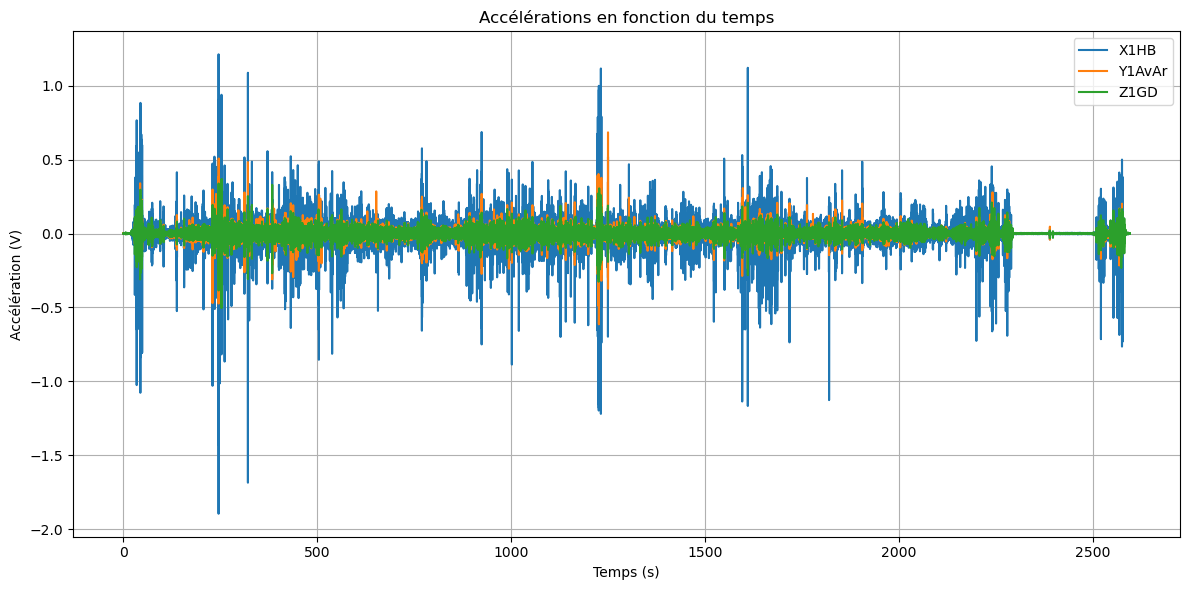

In [103]:
X1AvAr = df_reduced['X1HB'].to_numpy() - np.mean(df_reduced['X1HB'])
Y1GD = df_reduced['Y1AvAr'].to_numpy() - np.mean(df_reduced['Y1AvAr'])
Z1HB = df_reduced['Z1GD'].to_numpy() - np.mean(df_reduced['Z1GD'])
t = df_reduced['Time']
# Tracé des courbes
plt.figure(figsize=(12, 6))

plt.plot(t, X1AvAr, label='X1HB')
plt.plot(t, Y1GD, label='Y1AvAr')
plt.plot(t, Z1HB, label='Z1GD')

# Personnalisation des graphes
plt.xlabel('Temps (s)')
plt.ylabel('Accélération (V)')
plt.title('Accélérations en fonction du temps')
plt.legend()  # Affiche la légende
plt.grid(True)  # Ajoute une grille
plt.tight_layout()

plt.show()

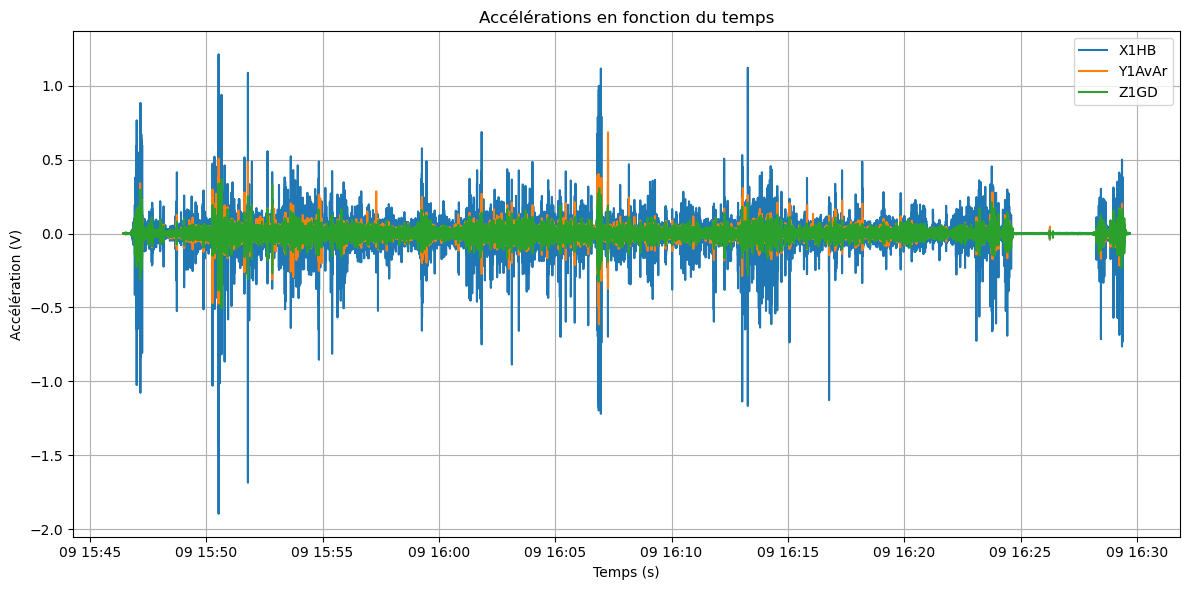

In [89]:
X1AvAr = df_reduced['X1HB'].to_numpy() - np.mean(df_reduced['X1HB'])
Y1GD = df_reduced['Y1AvAr'].to_numpy() - np.mean(df_reduced['Y1AvAr'])
Z1HB = df_reduced['Z1GD'].to_numpy() - np.mean(df_reduced['Z1GD'])
t = df_reduced['Time']
# Tracé des courbes
plt.figure(figsize=(12, 6))

plt.plot(t, X1AvAr, label='X1HB')
plt.plot(t, Y1GD, label='Y1AvAr')
plt.plot(t, Z1HB, label='Z1GD')

# Personnalisation des graphes
plt.xlabel('Temps (s)')
plt.ylabel('Accélération (V)')
plt.title('Accélérations en fonction du temps')
plt.legend()  # Affiche la légende
plt.grid(True)  # Ajoute une grille
plt.tight_layout()

plt.show()

<h1>Fonctions de traitement de signal</h1>

In [27]:
def comp_fft(df1, sensor="Cab1_BE_AV_G", sampling_sensor="time", plot=False):
    """
        Calcule la FFT d'un signal 1D.

        Parameters
        ----------
        df1 : DataFrame
            DataFrame contenant la colonne à analyser ainsi que la colonne de l'échantillonnage.
        sensor : str, optional
            Colonne à analyser, par défaut "Cab1_BE_AV_G".
        sampling_sensor : str, optional
            Type d'échantillonnage à considérer, par défaut "time".
        plot : bool, optional
            Afficher ou non le résultat, par défaut False.

        Returns
        -------
        xf : 1D array_like
            Liste des fréquences.
        fft_values : 1D array_like
            Liste des valeurs FFT associées à chaque fréquence de xf.
    """


    N = len(df1)
    if pd.api.types.is_datetime64_any_dtype(df1[sampling_sensor]):
      T = df1[sampling_sensor].diff().dt.total_seconds().mean()
    else:
      T = df1[sampling_sensor].diff().mean()  # Pour les cas où c'est déjà un float
    y = df1[sensor].values

    yf = fft(y)
    yf[0] /= 2
    xf = fftfreq(N, T)[: N // 2]

    fft_values = 2.0 / N * np.abs(yf[0 : N // 2])
    if plot:
        # Plot the PSD
        fig , axs = plt.subplots(1,1,sharex=True)
        axs.plot(xf, fft_values, color="red", alpha=0.9)
        axs.set_title('Fast Fourrier Transform (FFT) \n '+sensor)

        if sampling_sensor == "time":
            axs.set_xlabel('Frequency [$Hz$]')
        else :
            axs.set_xlabel('Frequency [$m^{-1}$]')

        axs.set_ylabel('FFT values')
        axs.legend()
        fig.tight_layout()


    return xf, fft_values

In [29]:
def comp_psd(df1, sensor, nperseg=512, sampling_sensor="time", plot=False):
    """
        Calcule la PSD d'un signal 1D.

        Parameters
        ----------
        df1 : DataFrame
            DataFrame contenant la colonne à analyser ainsi que la colonne de l'échantillonnage.
        sensor : str, optional
            Colonne à analyser, par défaut "Cab1_BE_AV_G".
        nperseg : int, optional
            Longueur de chaque segment, par défaut 512.
        sampling_sensor : str, optional
            Type d'échantillonnage à considérer, par défaut "time".
        plot : bool, optional
            Afficher ou non le résultat, par défaut False.

        Returns
        -------
        xf : 1D array_like
            Liste des fréquences.
        fft_values : 1D array_like
            Liste des valeurs PSD associées à chaque fréquence de xf.
    """
    df = df1.copy()
    #fs = int(1/np.abs(df[sampling_sensor].diff().mean()))
    if pd.api.types.is_datetime64_any_dtype(df1[sampling_sensor]):
      fs = int(1/np.abs(df[sampling_sensor].diff().dt.total_seconds().mean()))
    else:
      fs = int(1/np.abs(df[sampling_sensor].diff().mean()))  # Pour les cas où c'est déjà un float
    # Compute the PSD using the Welch method
    frequencies, psd = sn.welch(df[sensor].values, fs, nperseg=nperseg, average="mean")

    if plot :
        # Plot the PSD
        fig , axs = plt.subplots(1,1,sharex=True)
        # axs.semilogx(frequencies, psd)
        axs.plot(frequencies, psd, color="red")
        axs.set_title('Power Spectral Density (PSD) \n '+sensor)
        if sampling_sensor == "time":
            axs.set_xlabel('Frequency [$Hz$]')
        else :
            axs.set_xlabel('Frequency [$m^{-1}$]')

        axs.set_ylabel('Power/Frequency')
        fig.tight_layout()

    return frequencies, psd

In [31]:
def high_pass_filter(df, sensors, highcut_freq, order=4, sampling_sensor="time", plot=False):
    """
        Filtre passe-bas de Butterworth

        Parameters
        ----------
        df : DataFrame
            DataFrame contenant les colonnes à filtrer ainsi que la colonne de l'échantillonnage.
        sensors : list
            Liste des colonnes à filtrer.
        highcut_freq : float
            Fréquence de coupure.
        order : int, optional
            Ordre du filtre. Par défaut, 4.
        sampling_sensor : str, optional
            Choix entre un filtrage spatial ou temporel. Par défaut, 'time'.
        plot : bool, optional
            Afficher ou non le resultat , by default False

        Returns
        -------
        DataFrame
            DataFrame contenant les colonnes filtrées et renommées avec '_filt' ajouté à la fin de chaque nom de colonne.
    """
    df_filt = df.copy()
    #fs = 1 / df[sampling_sensor].diff().abs().median()
    if pd.api.types.is_datetime64_any_dtype(df[sampling_sensor]):
      fs = int(1/np.abs(df[sampling_sensor].diff().dt.total_seconds().abs().median()))
    else:
      fs = 1 / df[sampling_sensor].diff().abs().median()  # Pour les cas où c'est déjà un float
    nyq = 0.5 * fs
    high = highcut_freq / nyq
    b, a = sg.butter(order, high, btype="high")
    padlen = max(3 * max(len(a), len(b)), int(len(df)*0.01))
    if type(sensors) == str:
        df_filt[sensors] = sg.filtfilt(b, a, df_filt[sensors], padtype="even", padlen=padlen, method="pad")
    else:
        df_filt[sensors] = df_filt[sensors].apply(lambda x: sg.filtfilt(b, a, x, padtype="even", padlen=padlen, method="pad"))

    if plot :
        # domaine frequentiel avant et apres filtrage.
        if pd.api.types.is_datetime64_any_dtype(df[sampling_sensor]):
          Fe = int(1 / (df[sampling_sensor].diff().dt.total_seconds().mean()))
        else:
          Fe = int(1 / (df[sampling_sensor].diff().mean()))  # Pour les cas où c'est déjà un float
        sensor = sensors[0]
        xf1, fft_values1 = comp_fft(df, sensor, plot=False, sampling_sensor=sampling_sensor)
        xf2, fft_values2 = comp_fft(df_filt, sensor, plot=False, sampling_sensor=sampling_sensor)

        fig, axs = plt.subplots(2,1)

        axs[0].plot(df[sampling_sensor], df[sensor], color="red", alpha=0.6, label="Avant filtrage")
        axs[0].plot(df_filt[sampling_sensor], df_filt[sensor], color="blue", alpha=0.6, label="Après filtrage")
        axs[0].set_ylabel(sensor)
        axs[0].set_xlabel(sampling_sensor)
        axs[0].legend()

        axs[1].plot(
            xf1,
            fft_values1,
            color="red",
            alpha=0.3,
            label="Avant filtrage",
        )
        axs[1].plot(
            xf2,
            fft_values2,
            color="blue",
            alpha=0.3,
            label="Apres filtrage",
        )
        axs[1].set_ylabel("FFT values")

        if sampling_sensor == "time":
            unit = "$[Hz]$"
            axs[0].set_title("Filtrage de [ 0 - " + str(Fe//2) + " ] $Hz$ à [ 0 - " + str(highcut_freq) + " ] $Hz$ \n"+sensor)
        else :
            unit = "$[m^{-1}]$"
            axs[0].set_title("Filtrage de [ 0 - " + str(Fe//2) + " ] $m^{-1}$ à [ 0 - " + str(highcut_freq) + " ] $m^{-1}$ \n"+sensor)

        axs[1].set_xlabel('Frequency '+unit)
        axs[1].legend()
        fig.tight_layout()

    return df_filt

In [33]:
def low_pass_filter(df, sensors, lowcut_freq, order=4, sampling_sensor="time", plot=False):
    """
        Filtre passe-bas de Butterworth

        Parameters
        ----------
        df : DataFrame
            DataFrame contenant les colonnes à filtrer ainsi que la colonne de l'échantillonnage.
        sensors : list
            Liste des colonnes à filtrer.
        lowcut_freq : float
            Fréquence de coupure.
        order : int, optional
            Ordre du filtre. Par défaut, 4.
        sampling_sensor : str, optional
            Choix entre un filtrage spatial ou temporel. Par défaut, 'time'.
        plot : bool, optional
            Afficher ou non le resultat , by default False

        Returns
        -------
        DataFrame
            DataFrame contenant les colonnes filtrées et renommées avec '_filt' ajouté à la fin de chaque nom de colonne.
    """
    df_filt = df.copy()
    if pd.api.types.is_datetime64_any_dtype(df[sampling_sensor]):
      fs = int(1/np.abs(df[sampling_sensor].diff().dt.total_seconds().abs().median()))
    else:
      fs = 1 / df[sampling_sensor].diff().abs().median()  # Pour les cas où c'est déjà un float
    nyq = 0.5 * fs
    low = lowcut_freq / nyq
    b, a = sg.butter(order, low, btype="low")
    padlen = max(3 * max(len(a), len(b)), int(len(df)*0.01))
    if type(sensors) == str:
        df_filt[sensors] = sg.filtfilt(b, a, df_filt[sensors], padtype="even", padlen=padlen, method="pad")
    else:
        df_filt[sensors] = df_filt[sensors].apply(lambda x: sg.filtfilt(b, a, x, padtype="even", padlen=padlen, method="pad"))

    if plot :
        # domaine frequentiel avant et apres filtrage.
        if pd.api.types.is_datetime64_any_dtype(df[sampling_sensor]):
          Fe = int(1 / (df[sampling_sensor].diff().dt.total_seconds().mean()))
        else:
          Fe = int(1 / (df[sampling_sensor].diff().mean()))  # Pour les cas où c'est déjà un float
        sensor = sensors[0]
        xf1, fft_values1 = comp_fft(df, sensor, plot=False, sampling_sensor=sampling_sensor)
        xf2, fft_values2 = comp_fft(df_filt, sensor, plot=False, sampling_sensor=sampling_sensor)

        fig, axs = plt.subplots(2,1)

        axs[0].plot(df[sampling_sensor], df[sensor], color="red", alpha=0.6, label="Avant filtrage")
        axs[0].plot(df_filt[sampling_sensor], df_filt[sensor], color="blue", alpha=0.6, label="Après filtrage")
        axs[0].set_ylabel(sensor)
        axs[0].set_xlabel(sampling_sensor)
        axs[0].legend()

        axs[1].plot(
            xf1,
            fft_values1,
            color="red",
            alpha=0.3,
            label="Avant filtrage",
        )
        axs[1].plot(
            xf2,
            fft_values2,
            color="blue",
            alpha=0.3,
            label="Apres filtrage",
        )
        axs[1].set_ylabel("FFT values")

        if sampling_sensor == "time":
            unit = "$[Hz]$"
            axs[0].set_title("Filtrage de [ 0 - " + str(Fe//2) + " ] $Hz$ à [ 0 - " + str(lowcut_freq) + " ] $Hz$ \n"+sensor)
        else :
            unit = "$[m^{-1}]$"
            axs[0].set_title("Filtrage de [ 0 - " + str(Fe//2) + " ] $m^{-1}$ à [ 0 - " + str(lowcut_freq) + " ] $m^{-1}$ \n"+sensor)

        axs[1].set_xlabel('Frequency '+unit)
        axs[1].legend()
        fig.tight_layout()

    return df_filt

In [35]:
def band_pass_filter(df, sensors, fmin, fmax, order=2, sampling_sensor="time", plot=False):
    """
        Filtre passe-haut de Butterworth

        Parameters
        ----------
        df : DataFrame
            DataFrame contenant les colonnes à filtrer ainsi que la colonne de l'échantillonnage.
        sensors : list
            Liste des colonnes à filtrer.
        fmin : float
            Fréquence de coupure minimale.
        fmax : float
            Fréquence de coupure maximale.
        order : int, optional
            Ordre du filtre. Par défaut, 4.
        sampling_sensor : str, optional
            Choix entre un filtrage spatial ou temporel. Par défaut, 'time'.

        Returns
        -------
        DataFrame
            DataFrame contenant les colonnes filtrées et renommées avec '_filt' ajouté à la fin de chaque nom de colonne.
    """
    df_filt = df.copy()

    if pd.api.types.is_datetime64_any_dtype(df[sampling_sensor]):
      dt =  df[sampling_sensor].diff().dt.total_seconds().abs().mean()
    else:
      dt =  df[sampling_sensor].diff().abs().mean()  # Pour les cas où c'est déjà un float

    b, a = sg.butter(order, [2 * fmin * dt, 2 * fmax * dt], btype="bandpass")
    padlen = max(3 * max(len(a), len(b)), int(len(df)*0.01))
    if type(sensors) == str:
        df_filt[sensors] = sg.filtfilt(b, a, df_filt[sensors], padtype="even", padlen=padlen, method="pad")
    else:
        df_filt[sensors] = df_filt[sensors].apply(lambda x: sg.filtfilt(b, a, x, padtype="even", padlen=padlen, method="pad"))

    if plot:
        # domaine frequentiel avant et apres filtrage.
        if pd.api.types.is_datetime64_any_dtype(df[sampling_sensor]):
          Fe = int(1 / (df[sampling_sensor].diff().dt.total_seconds().mean()))
        else:
          Fe = int(1 / (df[sampling_sensor].diff().mean()))  # Pour les cas où c'est déjà un float
        sensor = sensors[0]
        xf1, fft_values1 = comp_fft(df, sensor, plot=False, sampling_sensor=sampling_sensor)
        xf2, fft_values2 = comp_fft(df_filt, sensor, plot=False, sampling_sensor=sampling_sensor)

        fig, axs = plt.subplots(2,1)

        axs[0].plot(df[sampling_sensor], df[sensor], color="red", alpha=0.6, label="Avant filtrage")
        axs[0].plot(df_filt[sampling_sensor], df_filt[sensor], color="blue", alpha=0.6, label="Après filtrage")
        axs[0].set_ylabel(sensor)
        axs[0].set_xlabel(sampling_sensor)
        axs[0].legend()

        axs[1].plot(
            xf1,
            fft_values1,
            color="red",
            alpha=0.3,
            label="Avant filtrage",
        )
        axs[1].plot(
            xf2,
            fft_values2,
            color="blue",
            alpha=0.3,
            label="Apres filtrage",
        )
        axs[1].set_ylabel("FFT values")

        if sampling_sensor == "time":
            unit = "$[Hz]$"
            axs[0].set_title("Filtrage de [ 0 - " + str(Fe//2) + " ] $Hz$ à [ " + str(fmin) + " - " + str(fmax) + " ] $Hz$ \n"+sensor)
        else :
            unit = "$[m^{-1}]$"
            axs[0].set_title("Filtrage de [ 0 - " + str(Fe//2) + " ] $m^{-1}$ à [ " + str(fmin) + " - " + str(fmax) + " ] $m^{-1}$ \n"+sensor)

        axs[1].set_xlabel('Frequency '+unit)
        axs[1].legend()
        fig.tight_layout()


    return df_filt

In [37]:
def band_stop_filter(df, sensors, fmin, fmax, order=2, sampling_sensor="time", plot=False):
    """
        Filtre passe-haut de Butterworth

        Parameters
        ----------
        df : DataFrame
            DataFrame contenant les colonnes à filtrer ainsi que la colonne de l'échantillonnage.
        sensors : list
            Liste des colonnes à filtrer.
        fmin : float
            Fréquence de coupure minimale.
        fmax : float
            Fréquence de coupure maximale.
        order : int, optional
            Ordre du filtre. Par défaut, 4.
        sampling_sensor : str, optional
            Choix entre un filtrage spatial ou temporel. Par défaut, 'time'.

        Returns
        -------
        DataFrame
            DataFrame contenant les colonnes filtrées.
    """
    df_filt = df.copy()
    if pd.api.types.is_datetime64_any_dtype(df[sampling_sensor]):
      dt =  df[sampling_sensor].diff().dt.total_seconds().abs().mean()
    else:
      dt =  df[sampling_sensor].diff().abs().mean()  # Pour les cas où c'est déjà un float

    b, a = sg.butter(order, [2 * fmin * dt, 2 * fmax * dt], btype="bandstop")
    padlen = max(3 * max(len(a), len(b)), int(len(df)*0.01))
    if type(sensors) == str:
        df_filt[sensors] = sg.filtfilt(b, a, df_filt[sensors], padtype="even", padlen=padlen, method="pad")
    else:
        df_filt[sensors] = df_filt[sensors].apply(lambda x: sg.filtfilt(b, a, x, padtype="even", padlen=padlen, method="pad"))

    if plot:
        # domaine frequentiel avant et apres filtrage.
        if pd.api.types.is_datetime64_any_dtype(df[sampling_sensor]):
          Fe = int(1 / (df[sampling_sensor].diff().dt.total_seconds().mean()))
        else:
          Fe = int(1 / (df[sampling_sensor].diff().mean()))  # Pour les cas où c'est déjà un float
        sensor = sensors[0]
        xf1, fft_values1 = comp_fft(df, sensor, plot=False, sampling_sensor=sampling_sensor)
        xf2, fft_values2 = comp_fft(df_filt, sensor, plot=False, sampling_sensor=sampling_sensor)

        fig, axs = plt.subplots(2,1, figsize=(45,20),constrained_layout=True)

        axs[0].plot(df[sampling_sensor], df[sensor], color="red", alpha=0.6, label="Avant filtrage")
        axs[0].plot(df_filt[sampling_sensor], df_filt[sensor], color="blue", alpha=0.6, label="Après filtrage")
        axs[0].set_ylabel(sensor)
        axs[0].set_xlabel(sampling_sensor)
        axs[0].legend()

        axs[1].plot(
            xf1,
            fft_values1,
            color="red",
            alpha=0.3,
            label="Avant filtrage",
        )
        axs[1].plot(
            xf2,
            fft_values2,
            color="blue",
            alpha=0.3,
            label="Apres filtrage",
        )
        axs[1].set_ylabel("FFT values")

        if sampling_sensor == "time":
            unit = "$[Hz]$"
            axs[0].set_title("Bande exclu :  [ " + str(fmin) + " - " + str(fmax) + " ] $Hz$ \n"+sensor)
        else :
            unit = "$[m^{-1}]$"
            axs[0].set_title("Bande exclu :  [ " + str(fmin) + " - " + str(fmax) + " ] $m^{-1}$ \n"+sensor)

        axs[1].set_xlabel('Frequency '+unit)
        axs[1].legend()
        fig.tight_layout()


    return df_filt

In [39]:
def sawp( df, sensor="Cab1_BE_AV_G", wavelet="cmor1.5-1.0", fmin=5, fmax=800, sampling_sensor="time", plot=False):
    """
    Calcul la SAWP d'un signal 1D

    Parameters
    ----------
    df : DataFrame
            DataFrame contenant la colonne à analyser ainsi que la colonne de l'échantillonnage.
    sensor : str, optional
        colonne à analyser, by default "Cab1_BE_AV_G"
    wavelet : str, optional
        ondelette mère, by default "cmor1.5-1.0"
    fmin : int, optional
        fréquence minimale à analyser, by default 5
    fmax : int, optional
        fréquence maximale, by default 800
    sampling_sensor : str, optional
        type d'echantillonnage à considerer, by default "time"
    plot : bool, optional
        Afficher ou non le resultat , by default False

    Returns
    -------
    1D array_like
        coefficients de la SAWP
    """
    #df["time_seconds"] = (df[sampling_sensor] - df[sampling_sensor].min()).dt.total_seconds()
    p = np.polyfit(df[sampling_sensor], df[sensor], 1)
    #p = np.polyfit(df["time_seconds"], df[sensor], 1)
    dat_notrend = df[sensor] - np.polyval(p, df[sampling_sensor])

    #dat_notrend = df[sensor] - np.polyval(p, df[sampling_sensor])
    std = dat_notrend.std()  # Standard deviation
    var = std**2  # Variance
    dat_norm = dat_notrend / std  # Normalized dataset

    #if pd.api.types.is_datetime64_any_dtype(df[sampling_sensor]):
    #  dt =  df[sampling_sensor].diff().dt.total_seconds().mean()
    #else:
    #  dt =  df[sampling_sensor].diff().mean()  # Pour les cas où c'est déjà un float
    dt =  df[sampling_sensor].diff().mean()
    print(dt)

    frequencies = np.array(np.linspace(fmin, fmax + 1, 65)) * dt  # normalize
    scales = pywt.frequency2scale(wavelet, frequencies)

    print(scales)

    wave, freqs = pywt.cwt(np.array(dat_norm), scales, wavelet, sampling_period=dt)

    power = (np.abs(wave)) ** 2
    power /= scales[:, None]

    n = df[sensor].size

    c_delta = 1
    scale_avg = (scales * np.ones((n, 1))).transpose()
    scale_avg = power / scale_avg  # As in Torrence and Compo (1998) equation 24
    scale_avg = var / c_delta * scale_avg[:, :].sum(axis=0)

    if plot:
        fig, axs = plt.subplots(2,1, sharex=True)
        axs[0].plot(df[sampling_sensor], df[sensor], "b-", linewidth=1, alpha=0.9)
        axs[1].plot(df[sampling_sensor], scale_avg, "k-", linewidth=1.5, alpha=0.9)
        axs[0].set_title(sensor + " SAWP")
        axs[1].set_xlabel(sampling_sensor)
        axs[0].set_ylabel(sensor)
        axs[1].set_ylabel(f"SAWP {fmin} - {fmax} ")

        fig.tight_layout()

    return scale_avg

In [41]:
def stft(
    df,
    sensor,
    pkd=-1,
    pkf=-1,
    nperseg=512,
    nfft = 512,
    noverlap=int(0.5 * 500),
    window="hann",
    sampling_sensor="time",
    log_plot = False,
    plot=False,
    get_axs = False,
):
    """
        Cette fonction est utilisée pour calculer la transformée de Fourier à court terme (STFT) du signal.

        Parameters
        ----------
        df : DataFrame
            DataFrame contenant la colonne à analyser ainsi que la colonne de l'échantillonnage.
        sensor : str
            colonne à analyser.
        pkd : float, optional
            point de depart du signal à analyser
        pkf : float, optional
            point d'arrivé du signal à analyser
        nperseg : int
            Longueur de chaque segment.
        nfft : int
            Longueur de chaque segment.
        noverlap : int
            Nombre de points de chevauchement entre les segments.
        window : str or tuple or array_like
            Fenêtre désirée à utiliser.
        sampling_sensor : str
            type d'echantillonnage à considerer.
        log_plot : bool, optional
            afficher le log10 du spectogramme
        plot : bool, optional
            Afficher ou non le resultat
        get_axs : bool, optional
            retourner la figure et ses axes

        Returns
        -------
        stft_matr : ndarray
            Résultats du spectre 2D (axe horizontal : temps, axe vertical : fréquence).
        freqs : ndarray
            Axe vertical des fréquences (en Hz).
        time : ndarray
            Axe horizontal du temps (en secondes).

        References
        ----------
        .. [1] Oppenheim, Alan V., Ronald W. Schafer, John R. Buck, “Discrete-Time Signal Processing”,
            Prentice Hall, 1999.
        .. [2] Daniel W. Griffin, Jae S. Lim, “Signal Estimation from Modified Short-Time Fourier Transform”,
            IEEE 1984, 10.1109/TASSP.1984.1164317
    """

    if pkf == -1:
        pkf = df[sampling_sensor].max()
    if pkd == -1:
        pkd = df[sampling_sensor].min()

    #if pd.api.types.is_datetime64_any_dtype(df[sampling_sensor]):
    #  fs = int(1/np.abs(df[sampling_sensor].diff().dt.total_seconds().abs().mean()))
    #else:
    #  fs = 1 / df[sampling_sensor].diff().abs().mean()  # Pour les cas où c'est déjà un float
    fs = 1 / df[sampling_sensor].diff().abs().mean()
    freqs, time, stft_matr = sg.stft(
        df[sensor],
        fs=fs,
        nperseg=nperseg,
        noverlap=noverlap,
        nfft = nfft,
        window=window,
        padded=True,
        boundary="zeros"
    )

    if plot:
        # draw the magnitute of the spectrum x_axis : pk, y_axis : frequence
        #df_sampling_seconds = (df[sampling_sensor] - df[sampling_sensor].iloc[0]).dt.total_seconds()
        #df_pk = np.interp(time, df_sampling_seconds, df_sampling_seconds)
        df_pk = np.interp(time, df[sampling_sensor] - df[sampling_sensor].iloc[0], df[sampling_sensor])

        fig, axs = plt.subplots(2,1, sharex=True)
        axs[0].plot(df[sampling_sensor], df[sensor], color="blue", alpha=0.8)
        axs[0].set_ylabel(sensor)

        if log_plot:
            axs[1].contourf(df_pk, freqs, np.log10(np.abs(stft_matr)), 100)
        else :
            axs[1].contourf(df_pk, freqs, np.abs(stft_matr) ** 2, 100)

        axs[1].set_xlabel(sampling_sensor)
        if sampling_sensor == "time":
            axs[1].set_ylabel("Frequence [Hz]")
        else :
            axs[1].set_ylabel("Frequence [$m^{-1}$]")
        axs[0].set_title(sensor + " STFT "+  "\n windows : " + window)
        fig.tight_layout()

        if get_axs:
            return stft_matr, freqs, time, fig, axs

    return stft_matr, freqs, time

In [43]:
def cwt( df, sensor, pkd=-1, pkf=-1, wavelet="cmorl1.5-1",  fmin=5, fmax=800, sampling_sensor="time",  plot=True, get_axs = False, ):
    """
        Cette fonction est utilisée pour calculer la transformée ondelette continue (CWT) du signal.

        Parameters
        ----------
        df : DataFrame
            DataFrame contenant la colonne à analyser ainsi que la colonne de l'échantillonnage.
        sensor : str
            colonne à analyser.
        pkd : float, optional
            point de depart du signal à analyser
        pkf : float, optional
            point d'arrivé du signal à analyser
        wavelet : str, optional
            ondelette mère, by default "cmorl1.5-1"
        fmin : int, optional
            fréquence minimale à analyser, by default 5
        fmax : int, optional
            fréquence maximale, by default 800
        sampling_sensor : str, optional
            Choix entre un filtrage spatial ou temporel. Par défaut, 'time'.
        plot : bool, optional
            Afficher ou non le resultat , by default False

        Returns
        -------
        cwtmatr : ndarray
            Résultats du spectre 2D (axe horizontal : temps, axe vertical : fréquence).
        freqs : ndarray
            Axe vertical des fréquences.

    """
    if pkf == -1:
        pkf = df[sampling_sensor].max()
    if pkd == -1:
        pkd = df[sampling_sensor].min()
    df_filt = df.loc[(df[sampling_sensor] >= pkd) & (df[sampling_sensor] <= pkf)]

    dt =  df_filt[sampling_sensor].diff().abs().mean()  # Pour les cas où c'est déjà un float
    dt = np.round(dt, 6)
    frequencies = np.linspace(fmin, fmax, 65)
    frequencies = np.array(frequencies) * dt # normalise frequencies
    scales = pywt.frequency2scale(wavelet, frequencies)
    cwtmatr, freqs = pywt.cwt(
        df_filt[sensor], scales, wavelet, sampling_period=dt
    )

    if plot:
        # draw the magnitute of the spectrum x_axis : pk, y_axis : frequence
        fig, axs = plt.subplots(2,1, sharex=True)
        axs[1].contourf(df_filt[sampling_sensor], freqs, np.squeeze(np.abs(cwtmatr)**2), 100)
        axs[0].plot(df[sampling_sensor], df[sensor], color="blue", alpha=0.8)
        axs[0].set_title(sensor + " CWT \nWavelet : [" + wavelet + "]")
        axs[0].set_ylabel(sensor)
        axs[1].set_xlabel(sampling_sensor)
        axs[1].grid(False)
        if sampling_sensor == "time":
            axs[1].set_ylabel("Frequence [Hz]")
        else :
            axs[1].set_ylabel("Frequence [$m^{-1}$]")
        fig.tight_layout()

        if get_axs:
            return cwtmatr, freqs, fig, axs

    return cwtmatr, freqs

In [45]:
def get_env_signal(df1, sensor, mode="upper", plot=False, sampling_sensor="time", ymin=10):

    """
        Extrait l'envelloppe inferieure ou superieure d'un signal

        Parameters
        ----------
        df : DataFrame
            DataFrame contenant les colonnes à filtrer ainsi que la colonne de l'échantillonnage.
        sensor : str
            colonnes à analyser.
        mode : str
            envelloppe inferieur (lower) ou superieur (upper), Par défaut upper.
        plot : bool, optional
            Afficher ou non le resultat , by default False

        Returns
        -------
        DataFrame
            DataFrame contenant l'envelloppe du signal.
    """

    df = df1.copy()
    df["env_" + mode + "_" + sensor] = emd.sift.interp_envelope(
        df[sensor].values, mode=mode, interp_method="pchip"
    )
    df = df.loc[df[sensor] == df["env_" + mode + "_" + sensor]]
    df = df.loc[df[sensor].abs()>ymin]
    if plot:
        fig, axs = plt.subplots(1,1,sharex=True)
        axs.plot(df1[sampling_sensor], df1[sensor], alpha=0.3, color="red", label=sensor)
        axs.scatter(df[sampling_sensor], df["env_" + mode + "_" + sensor], alpha=0.8, color="blue", label=mode+" envelope of "+sensor)
        axs.set_xlabel(sampling_sensor)
        axs.set_ylabel(sensor)
        axs.legend()
        fig.tight_layout()

    return df

In [49]:
df_reduced.columns = df_reduced.columns.str.strip()

<h1>FFT des canaux du premier accéléromètre</h1>

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


(array([0.00000000e+00, 3.85316416e-04, 7.70632832e-04, ...,
        5.00012783e+02, 5.00013168e+02, 5.00013554e+02]),
 array([3.39658743e-03, 4.66968544e-04, 3.06044161e-04, ...,
        3.00488456e-05, 1.81284136e-05, 1.68073587e-05]))

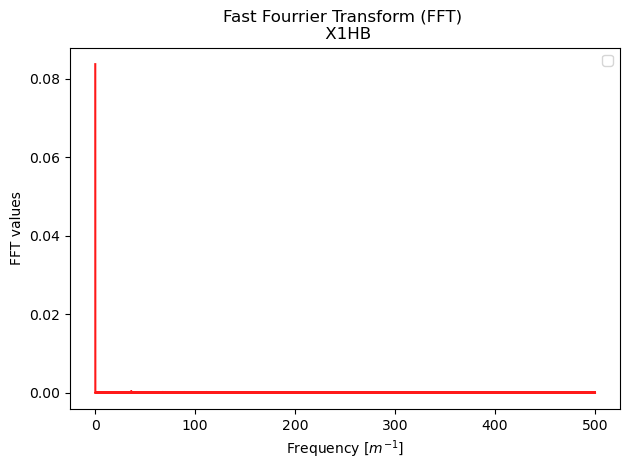

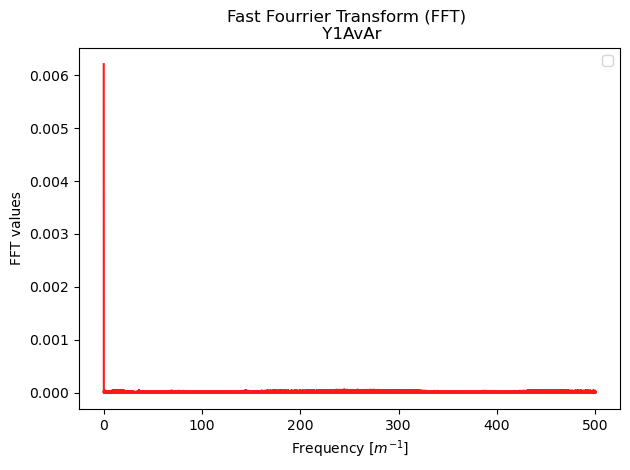

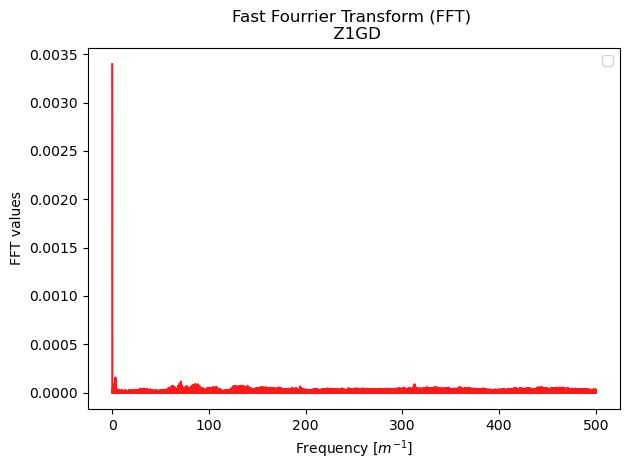

In [53]:
comp_fft(df_reduced, sensor="X1HB", sampling_sensor="Time", plot=True)
comp_fft(df_reduced, sensor="Y1AvAr", sampling_sensor="Time", plot=True)
comp_fft(df_reduced, sensor="Z1GD", sampling_sensor="Time", plot=True)

<h1>PSD des canaux du premier accéléromètre</h1>

(array([  0.      ,   1.953125,   3.90625 ,   5.859375,   7.8125  ,
          9.765625,  11.71875 ,  13.671875,  15.625   ,  17.578125,
         19.53125 ,  21.484375,  23.4375  ,  25.390625,  27.34375 ,
         29.296875,  31.25    ,  33.203125,  35.15625 ,  37.109375,
         39.0625  ,  41.015625,  42.96875 ,  44.921875,  46.875   ,
         48.828125,  50.78125 ,  52.734375,  54.6875  ,  56.640625,
         58.59375 ,  60.546875,  62.5     ,  64.453125,  66.40625 ,
         68.359375,  70.3125  ,  72.265625,  74.21875 ,  76.171875,
         78.125   ,  80.078125,  82.03125 ,  83.984375,  85.9375  ,
         87.890625,  89.84375 ,  91.796875,  93.75    ,  95.703125,
         97.65625 ,  99.609375, 101.5625  , 103.515625, 105.46875 ,
        107.421875, 109.375   , 111.328125, 113.28125 , 115.234375,
        117.1875  , 119.140625, 121.09375 , 123.046875, 125.      ,
        126.953125, 128.90625 , 130.859375, 132.8125  , 134.765625,
        136.71875 , 138.671875, 140.625   , 142.

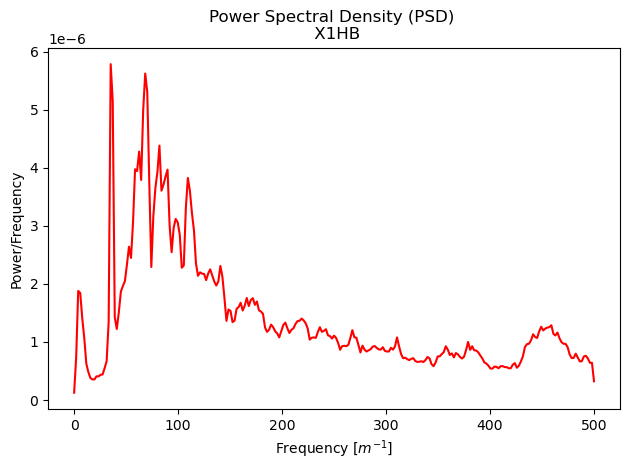

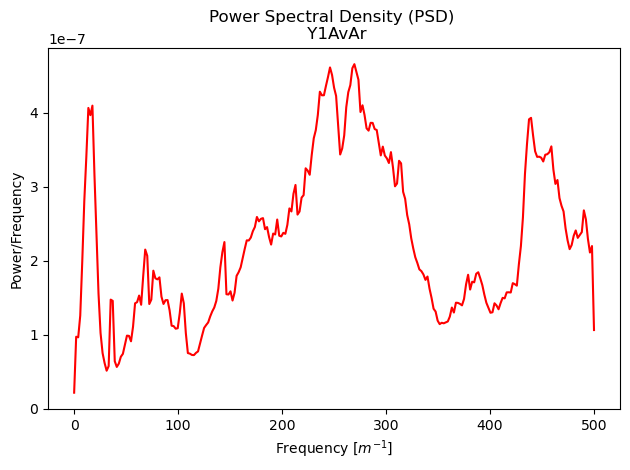

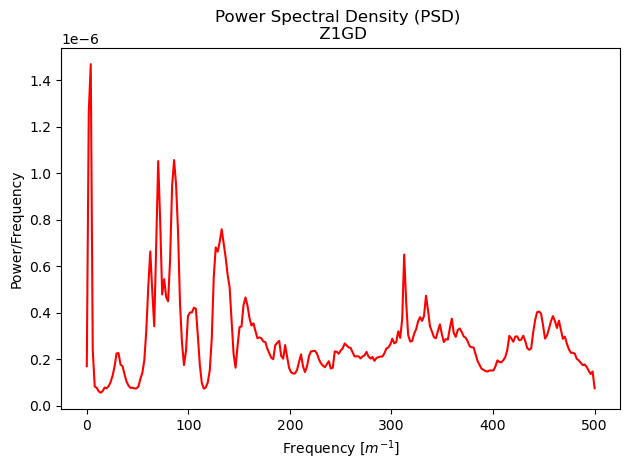

In [55]:
comp_psd(df_reduced, sensor="X1HB", nperseg=512, sampling_sensor="Time", plot=True)
comp_psd(df_reduced, sensor="Y1AvAr", nperseg=512, sampling_sensor="Time", plot=True)
comp_psd(df_reduced, sensor="Z1GD", nperseg=512, sampling_sensor="Time", plot=True)

<h1>On zoome sur le pic qui nous intéresse</h1>

In [57]:
def comp_psd_2(df1, sensor, nperseg=512, sampling_sensor="time", plot=False):

    df = df1.copy()
    #fs = int(1/np.abs(df[sampling_sensor].diff().mean()))
    if pd.api.types.is_datetime64_any_dtype(df1[sampling_sensor]):
      fs = int(1/np.abs(df[sampling_sensor].diff().dt.total_seconds().mean()))
    else:
      fs = int(1/np.abs(df[sampling_sensor].diff().mean()))  # Pour les cas où c'est déjà un float
    # Compute the PSD using the Welch method
    frequencies, psd = sn.welch(df[sensor].values, fs, nperseg=nperseg, average="mean")

    if plot :
        # Plot the PSD
        fig , axs = plt.subplots(1,1,sharex=True)
        # axs.semilogx(frequencies, psd)
        axs.plot(frequencies, psd, color="red")
        axs.set_title('Power Spectral Density (PSD) \n '+sensor)
        if sampling_sensor == "time":
            axs.set_xlabel('Frequency [$Hz$]')
        else :
            axs.set_xlabel('Frequency [$m^{-1}$]')

        axs.set_ylabel('Power/Frequency')

        plt.xlim(0,100)
        
        fig.tight_layout()

    return frequencies, psd

(array([  0.      ,   1.953125,   3.90625 ,   5.859375,   7.8125  ,
          9.765625,  11.71875 ,  13.671875,  15.625   ,  17.578125,
         19.53125 ,  21.484375,  23.4375  ,  25.390625,  27.34375 ,
         29.296875,  31.25    ,  33.203125,  35.15625 ,  37.109375,
         39.0625  ,  41.015625,  42.96875 ,  44.921875,  46.875   ,
         48.828125,  50.78125 ,  52.734375,  54.6875  ,  56.640625,
         58.59375 ,  60.546875,  62.5     ,  64.453125,  66.40625 ,
         68.359375,  70.3125  ,  72.265625,  74.21875 ,  76.171875,
         78.125   ,  80.078125,  82.03125 ,  83.984375,  85.9375  ,
         87.890625,  89.84375 ,  91.796875,  93.75    ,  95.703125,
         97.65625 ,  99.609375, 101.5625  , 103.515625, 105.46875 ,
        107.421875, 109.375   , 111.328125, 113.28125 , 115.234375,
        117.1875  , 119.140625, 121.09375 , 123.046875, 125.      ,
        126.953125, 128.90625 , 130.859375, 132.8125  , 134.765625,
        136.71875 , 138.671875, 140.625   , 142.

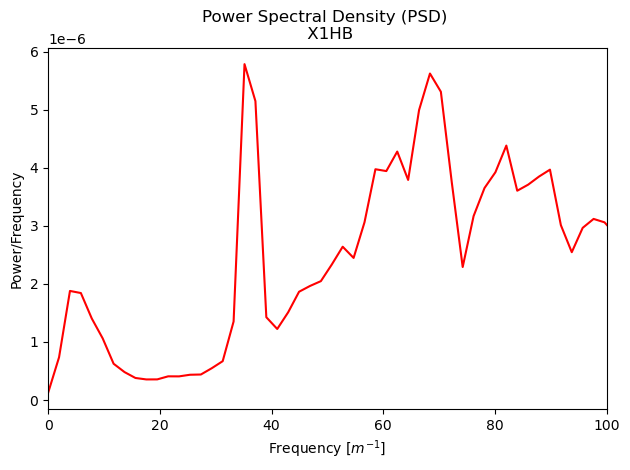

In [59]:
comp_psd_2(df_reduced, sensor="X1HB", nperseg=512, sampling_sensor="Time", plot=True)

In [61]:
def band_pass_filter_2(df, sensors, fmin, fmax, order=2, sampling_sensor="time", plot=False):

    df_filt = df.copy()

    if pd.api.types.is_datetime64_any_dtype(df[sampling_sensor]):
      dt =  df[sampling_sensor].diff().dt.total_seconds().abs().mean()
    else:
      dt =  df[sampling_sensor].diff().abs().mean()  # Pour les cas où c'est déjà un float

    b, a = sg.butter(order, [2 * fmin * dt, 2 * fmax * dt], btype="bandpass")
    padlen = max(3 * max(len(a), len(b)), int(len(df)*0.01))
    if type(sensors) == str:
        df_filt[sensors] = sg.filtfilt(b, a, df_filt[sensors], padtype="even", padlen=padlen, method="pad")
    else:
        df_filt[sensors] = df_filt[sensors].apply(lambda x: sg.filtfilt(b, a, x, padtype="even", padlen=padlen, method="pad"))

    if plot:
        # domaine frequentiel avant et apres filtrage.
        if pd.api.types.is_datetime64_any_dtype(df[sampling_sensor]):
          Fe = int(1 / (df[sampling_sensor].diff().dt.total_seconds().mean()))
        else:
          Fe = int(1 / (df[sampling_sensor].diff().mean()))  # Pour les cas où c'est déjà un float
        sensor = sensors[0]
        xf1, fft_values1 = comp_fft(df, sensor, plot=False, sampling_sensor=sampling_sensor)
        xf2, fft_values2 = comp_fft(df_filt, sensor, plot=False, sampling_sensor=sampling_sensor)

        fig, axs = plt.subplots(2,1)

        axs[0].plot(df[sampling_sensor], df[sensor], color="red", alpha=0.6, label="Avant filtrage")
        axs[0].plot(df_filt[sampling_sensor], df_filt[sensor], color="blue", alpha=0.6, label="Après filtrage")
        axs[0].set_ylabel(sensor)
        axs[0].set_xlabel(sampling_sensor)
        axs[0].legend()

        axs[1].plot(
            xf1,
            fft_values1,
            color="red",
            alpha=0.3,
            label="Avant filtrage",
        )
        axs[1].plot(
            xf2,
            fft_values2,
            color="blue",
            alpha=0.3,
            label="Apres filtrage",
        )
        axs[1].set_ylabel("FFT values")

        if sampling_sensor == "time":
            unit = "$[Hz]$"
            axs[0].set_title("Filtrage de [ 0 - " + str(Fe//2) + " ] $Hz$ à [ " + str(fmin) + " - " + str(fmax) + " ] $Hz$ \n"+sensor)
        else :
            unit = "$[m^{-1}]$"
            axs[0].set_title("Filtrage de [ 0 - " + str(Fe//2) + " ] $m^{-1}$ à [ " + str(fmin) + " - " + str(fmax) + " ] $m^{-1}$ \n"+sensor)

        axs[1].set_xlabel('Frequency '+unit)
        axs[1].legend()
        fig.tight_layout()

        plt.xlim(0,100)


    return df_filt

<h1>On filtre le signal sur le pic à étudier</h1>

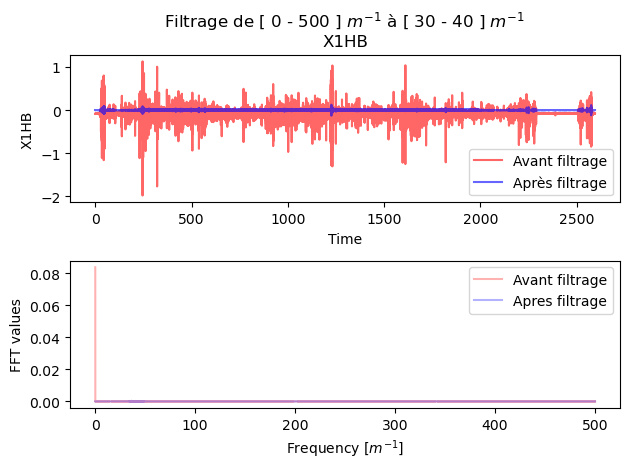

In [63]:
filt = band_pass_filter(df_reduced, ["X1HB"], fmin=30, fmax=40, order=2, sampling_sensor="Time", plot=True)

<h1>SAWP du signal filtré</h1>

0.000999972123123705
[33.33426259 33.14437295 32.95663448 32.77101084 32.58746648 32.40596667
 32.22647743 32.04896553 31.87339849 31.69974451 31.5279725  31.35805202
 31.1899533  31.0236472  30.85910519 30.69629936 30.53520237 30.37578746
 30.21802841 30.06189956 29.90737578 29.75443244 29.60304541 29.45319106
 29.30484623 29.15798823 29.01259482 28.86864419 28.72611498 28.58498623
 28.44523741 28.30684837 28.16979937 28.03407103 27.89964436 27.76650072
 27.63462183 27.50398976 27.3745869  27.24639599 27.11940007 26.99358253
 26.86892702 26.74541754 26.62303834 26.50177398 26.3816093  26.26252941
 26.14451968 26.02756575 25.91165351 25.79676911 25.68289894 25.57002963
 25.45814804 25.34724126 25.2372966  25.1283016  25.02024401 24.91311178
 24.80689309 24.70157629 24.59714995 24.49360282 24.39092385]


array([3.53469882e-08, 3.74228755e-08, 4.07855005e-08, ...,
       7.39034790e-08, 7.46969869e-08, 7.21425061e-08])

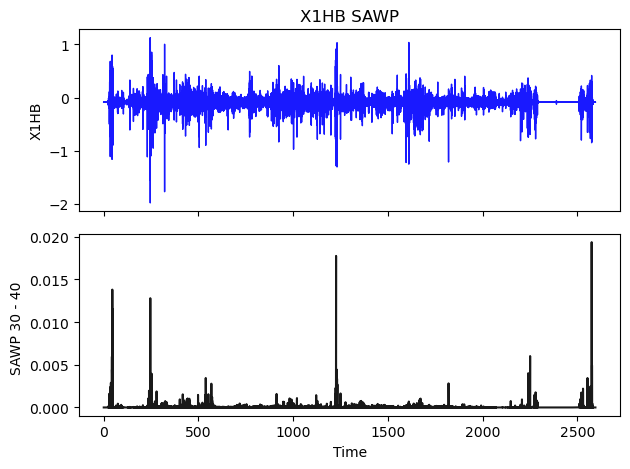

In [65]:
sawp(df_reduced, sensor="X1HB", wavelet="cmor1.5-1.0", fmin=30, fmax=40, sampling_sensor="Time", plot=True)

0.000999972123123705
[33.33426259 33.14437295 32.95663448 32.77101084 32.58746648 32.40596667
 32.22647743 32.04896553 31.87339849 31.69974451 31.5279725  31.35805202
 31.1899533  31.0236472  30.85910519 30.69629936 30.53520237 30.37578746
 30.21802841 30.06189956 29.90737578 29.75443244 29.60304541 29.45319106
 29.30484623 29.15798823 29.01259482 28.86864419 28.72611498 28.58498623
 28.44523741 28.30684837 28.16979937 28.03407103 27.89964436 27.76650072
 27.63462183 27.50398976 27.3745869  27.24639599 27.11940007 26.99358253
 26.86892702 26.74541754 26.62303834 26.50177398 26.3816093  26.26252941
 26.14451968 26.02756575 25.91165351 25.79676911 25.68289894 25.57002963
 25.45814804 25.34724126 25.2372966  25.1283016  25.02024401 24.91311178
 24.80689309 24.70157629 24.59714995 24.49360282 24.39092385]


array([9.21976740e-09, 9.80180599e-09, 1.04407985e-08, ...,
       2.60456372e-08, 2.48854291e-08, 2.35720411e-08])

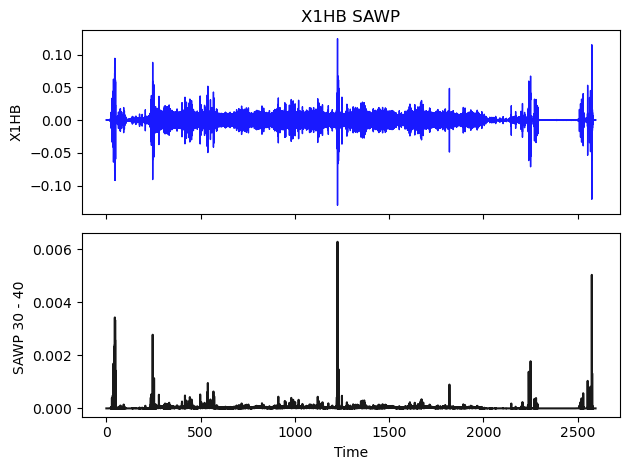

In [67]:
sawp(filt, sensor="X1HB", wavelet="cmor1.5-1.0", fmin=30, fmax=40, sampling_sensor="Time", plot=True)

<h1>On modifie la fonction SAWP pour donner en sortie les valeurs d'odométrie où l'amplitude de la SAWP en cette position est supérieure à un seuil</h1>

In [125]:
def sawp_2(df, sensor="Cab1_BE_AV_G", wavelet="cmor1.5-1.0", fmin=5, fmax=800, sampling_sensor="time", plot=False, threshold=1):
    """
    Calcul la SAWP d'un signal 1D et retourne les timestamps où l'amplitude est supérieure à un seuil.
    """

    p = np.polyfit(df[sampling_sensor], df[sensor], 1)
    dat_notrend = df[sensor] - np.polyval(p, df[sampling_sensor])

    std = dat_notrend.std()  # Standard deviation
    var = std**2  # Variance
    dat_norm = dat_notrend / std  # Normalized dataset

    dt = df[sampling_sensor].diff().mean()
    frequencies = np.array(np.linspace(fmin, fmax + 1, 65)) * dt  # normalize
    scales = pywt.frequency2scale(wavelet, frequencies)

    wave, freqs = pywt.cwt(np.array(dat_norm), scales, wavelet, sampling_period=dt)

    power = (np.abs(wave)) ** 2
    power /= scales[:, None]

    n = df[sensor].size
    c_delta = 1
    scale_avg = (scales * np.ones((n, 1))).transpose()
    scale_avg = power / scale_avg  # As in Torrence and Compo (1998) equation 24
    scale_avg = var / c_delta * scale_avg[:, :].sum(axis=0)

    if plot:
        fig, axs = plt.subplots(2,1, sharex=True)
        axs[0].plot(df[sampling_sensor], df[sensor], "b-", linewidth=1, alpha=0.9)
        axs[1].plot(df[sampling_sensor], scale_avg, "k-", linewidth=1.5, alpha=0.9)
        axs[0].set_title(sensor + " SAWP")
        axs[1].set_xlabel(sampling_sensor)
        axs[0].set_ylabel(sensor)
        axs[1].set_ylabel(f"SAWP {fmin} - {fmax} ")

        fig.tight_layout()

    # Trouver les indices où l'amplitude est supérieure à un seuil
    indices_above_threshold = np.where(scale_avg > threshold)[0]

    # Obtenir les secondes correspondantes
    seconds_above_threshold = df[sampling_sensor].iloc[indices_above_threshold]

    # Récupérer le timestamp de référence (premier timestamp de votre série originale)
    reference_timestamp = pd.to_datetime('15:46:26.2600 09/09/2024', format='%H:%M:%S.%f %d/%m/%Y')

    # Reconversion des secondes en timestamps
    timestamps_above_threshold = [reference_timestamp + pd.Timedelta(seconds=seconds) for seconds in seconds_above_threshold]

    return scale_avg, timestamps_above_threshold

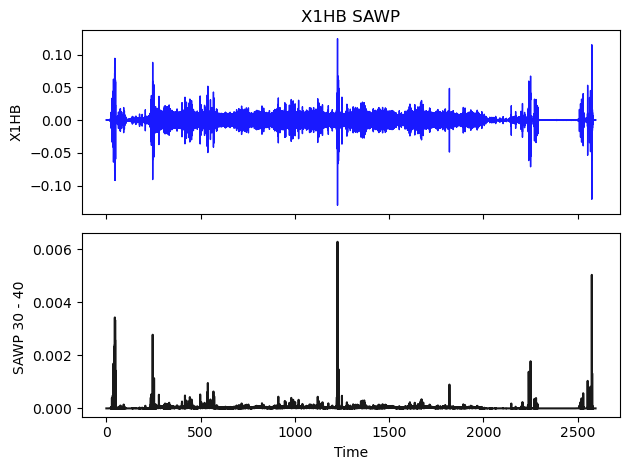

In [127]:
# Exécution de la fonction
scale_avg, timestamp_above_threshold = sawp_2(filt, sensor="X1HB", wavelet="cmor1.5-1.0", fmin=30, fmax=40, sampling_sensor="Time", plot=True, threshold=0.002)

In [129]:
# Affichage des timestamps où l'amplitude est supérieure au seuil
print("Timestamps où l'amplitude SAWP est supérieure au seuil:")
print(timestamp_above_threshold)

Timestamps où l'amplitude SAWP est supérieure au seuil:
[Timestamp('2024-09-09 15:47:10.377350'), Timestamp('2024-09-09 15:47:10.378350'), Timestamp('2024-09-09 15:47:10.379350'), Timestamp('2024-09-09 15:47:10.380350'), Timestamp('2024-09-09 15:47:10.381350'), Timestamp('2024-09-09 15:47:10.382350'), Timestamp('2024-09-09 15:47:10.383350'), Timestamp('2024-09-09 15:47:10.384350'), Timestamp('2024-09-09 15:47:10.385350'), Timestamp('2024-09-09 15:47:10.386350'), Timestamp('2024-09-09 15:47:10.387350'), Timestamp('2024-09-09 15:47:10.388350'), Timestamp('2024-09-09 15:47:10.389350'), Timestamp('2024-09-09 15:47:10.390350'), Timestamp('2024-09-09 15:47:10.391350'), Timestamp('2024-09-09 15:47:10.392350'), Timestamp('2024-09-09 15:47:10.393350'), Timestamp('2024-09-09 15:47:10.394350'), Timestamp('2024-09-09 15:47:10.395350'), Timestamp('2024-09-09 15:47:10.396350'), Timestamp('2024-09-09 15:47:10.397350'), Timestamp('2024-09-09 15:47:10.398350'), Timestamp('2024-09-09 15:47:10.399350'), 

<h1>Transformée de Hilbert</h1>

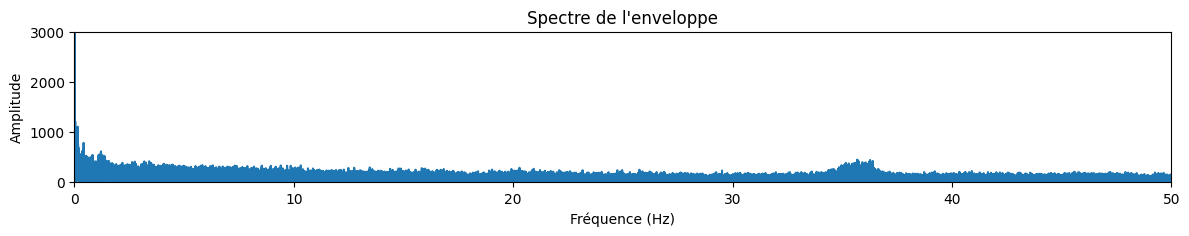

In [78]:
from scipy.signal import hilbert
fe = 1000
analytic_signal = hilbert(df_reduced['X1HB'])
envelope = np.abs(analytic_signal)

fft_envelope = np.fft.fft(envelope)
freqs = np.fft.fftfreq(len(envelope), 1/fe)

plt.figure(figsize=(12, 6))

# Spectre de l'enveloppe
plt.subplot(3, 1, 3)
plt.plot(freqs[:len(freqs)//2], np.abs(fft_envelope[:len(freqs)//2]))
plt.title('Spectre de l\'enveloppe')
plt.xlabel('Fréquence (Hz)')
plt.ylabel('Amplitude')
plt.ylim(0, 3000)
plt.xlim(0, 50)  # Zoom sur les basses fréquences
plt.tight_layout()
plt.show()

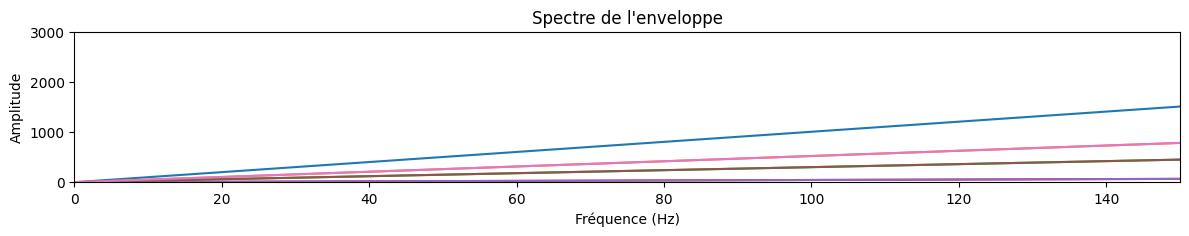

In [79]:
from scipy.signal import hilbert
fe = 1000
analytic_signal = hilbert(filt)
envelope = np.abs(analytic_signal)

fft_envelope = np.fft.fft(envelope)
freqs = np.fft.fftfreq(len(envelope), 1/fe)

plt.figure(figsize=(12, 6))

# Spectre de l'enveloppe
plt.subplot(3, 1, 3)
plt.plot(freqs[:len(freqs)//2], np.abs(fft_envelope[:len(freqs)//2]))
plt.title('Spectre de l\'enveloppe')
plt.xlabel('Fréquence (Hz)')
plt.ylabel('Amplitude')
plt.ylim(0, 3000)
plt.xlim(0, 150)  # Zoom sur les basses fréquences
plt.tight_layout()
plt.show()

(array([0.00000000e+00, 2.73218378e-04, 5.46436756e-04, ...,
        5.00016134e+02, 5.00016407e+02, 5.00016680e+02]),
 array([4.11226605e-03, 1.99361216e-04, 2.39170664e-04, ...,
        6.34497572e-06, 1.46572404e-05, 9.92955771e-06]))

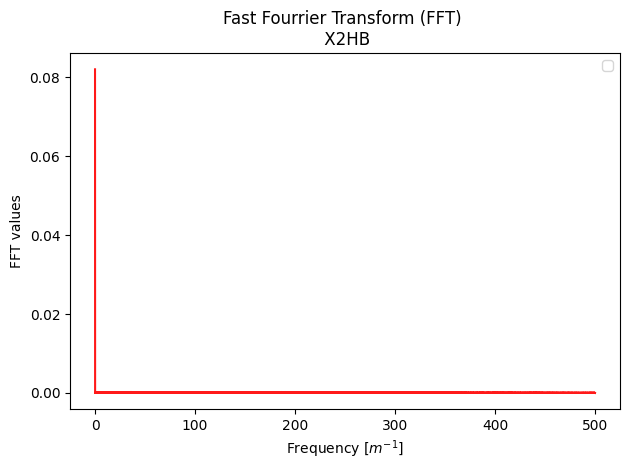

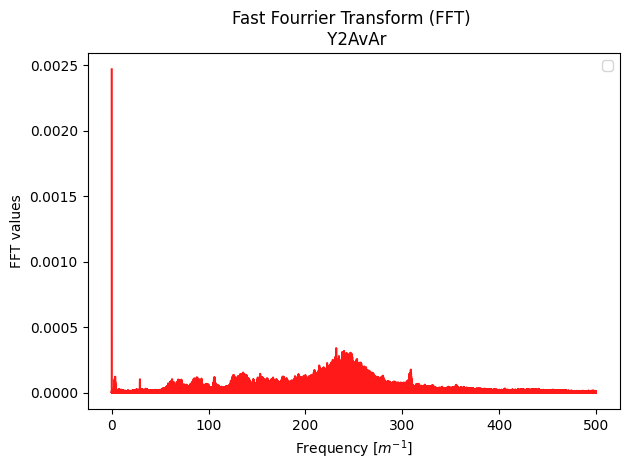

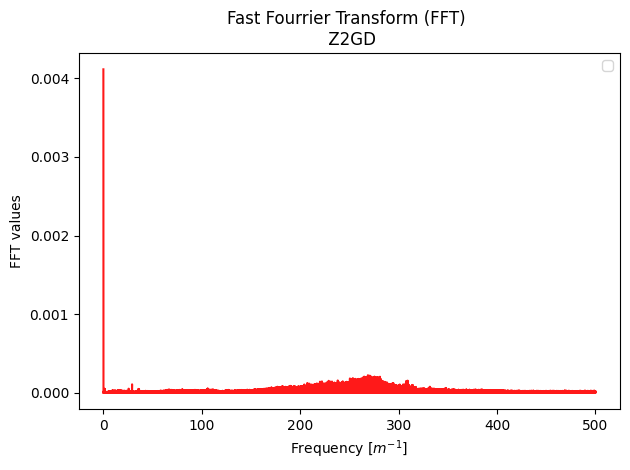

In [80]:
comp_fft(df_reduced, sensor="X2HB", sampling_sensor="Time", plot=True)
comp_fft(df_reduced, sensor="Y2AvAr", sampling_sensor="Time", plot=True)
comp_fft(df_reduced, sensor="Z2GD", sampling_sensor="Time", plot=True)

(array([  0.      ,   1.953125,   3.90625 ,   5.859375,   7.8125  ,
          9.765625,  11.71875 ,  13.671875,  15.625   ,  17.578125,
         19.53125 ,  21.484375,  23.4375  ,  25.390625,  27.34375 ,
         29.296875,  31.25    ,  33.203125,  35.15625 ,  37.109375,
         39.0625  ,  41.015625,  42.96875 ,  44.921875,  46.875   ,
         48.828125,  50.78125 ,  52.734375,  54.6875  ,  56.640625,
         58.59375 ,  60.546875,  62.5     ,  64.453125,  66.40625 ,
         68.359375,  70.3125  ,  72.265625,  74.21875 ,  76.171875,
         78.125   ,  80.078125,  82.03125 ,  83.984375,  85.9375  ,
         87.890625,  89.84375 ,  91.796875,  93.75    ,  95.703125,
         97.65625 ,  99.609375, 101.5625  , 103.515625, 105.46875 ,
        107.421875, 109.375   , 111.328125, 113.28125 , 115.234375,
        117.1875  , 119.140625, 121.09375 , 123.046875, 125.      ,
        126.953125, 128.90625 , 130.859375, 132.8125  , 134.765625,
        136.71875 , 138.671875, 140.625   , 142.

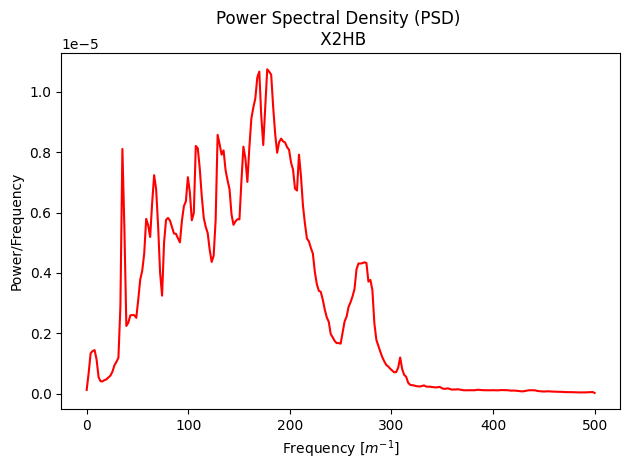

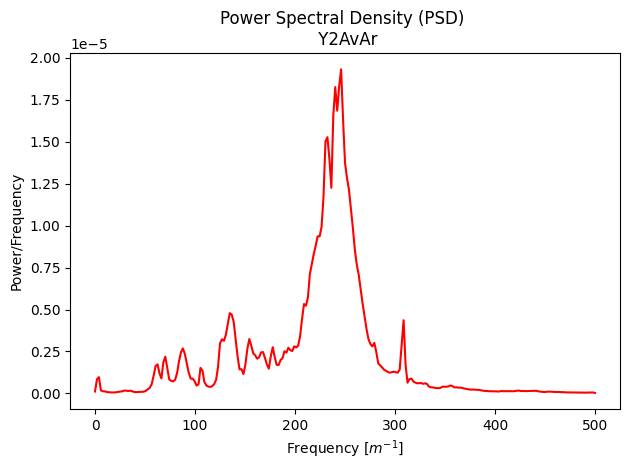

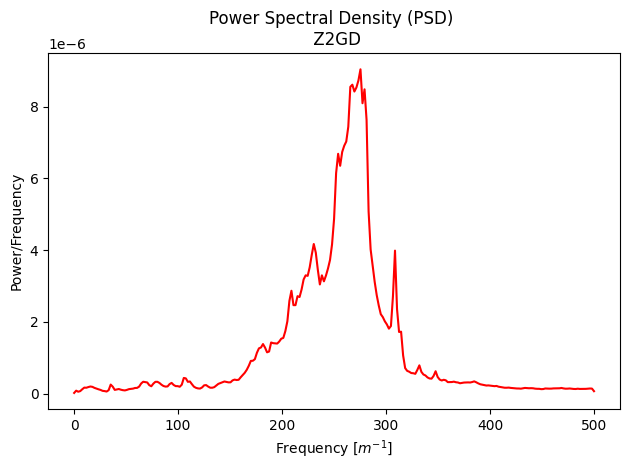

In [81]:
comp_psd(df_reduced, sensor="X2HB", nperseg=512, sampling_sensor="Time", plot=True)
comp_psd(df_reduced, sensor="Y2AvAr", nperseg=512, sampling_sensor="Time", plot=True)
comp_psd(df_reduced, sensor="Z2GD", nperseg=512, sampling_sensor="Time", plot=True)

(array([  0.      ,   1.953125,   3.90625 ,   5.859375,   7.8125  ,
          9.765625,  11.71875 ,  13.671875,  15.625   ,  17.578125,
         19.53125 ,  21.484375,  23.4375  ,  25.390625,  27.34375 ,
         29.296875,  31.25    ,  33.203125,  35.15625 ,  37.109375,
         39.0625  ,  41.015625,  42.96875 ,  44.921875,  46.875   ,
         48.828125,  50.78125 ,  52.734375,  54.6875  ,  56.640625,
         58.59375 ,  60.546875,  62.5     ,  64.453125,  66.40625 ,
         68.359375,  70.3125  ,  72.265625,  74.21875 ,  76.171875,
         78.125   ,  80.078125,  82.03125 ,  83.984375,  85.9375  ,
         87.890625,  89.84375 ,  91.796875,  93.75    ,  95.703125,
         97.65625 ,  99.609375, 101.5625  , 103.515625, 105.46875 ,
        107.421875, 109.375   , 111.328125, 113.28125 , 115.234375,
        117.1875  , 119.140625, 121.09375 , 123.046875, 125.      ,
        126.953125, 128.90625 , 130.859375, 132.8125  , 134.765625,
        136.71875 , 138.671875, 140.625   , 142.

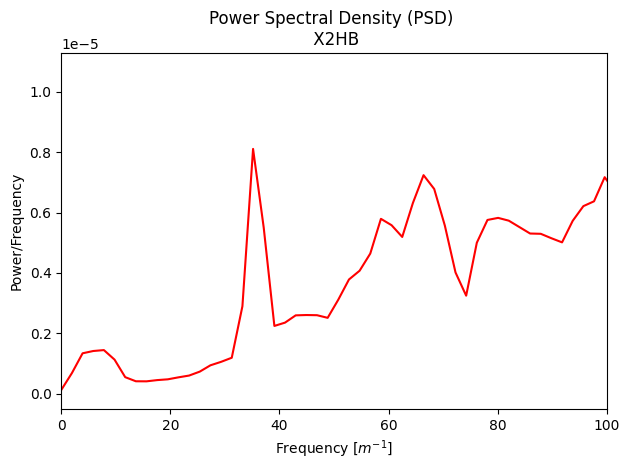

In [83]:
comp_psd_2(df_reduced, sensor="X2HB", nperseg=512, sampling_sensor="Time", plot=True)

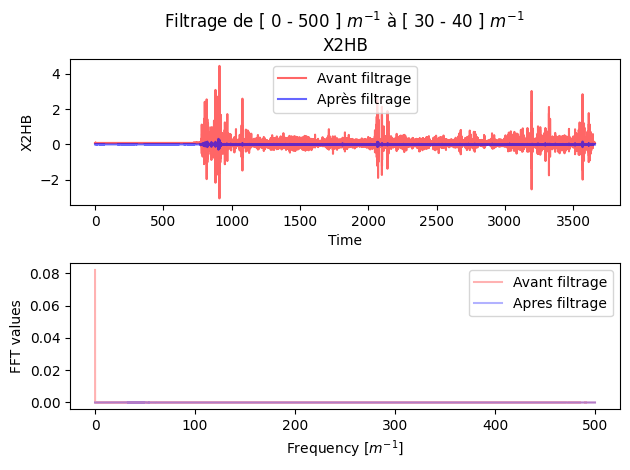

In [84]:
filt = band_pass_filter(df_reduced, ["X2HB"], fmin=30, fmax=40, order=2, sampling_sensor="Time", plot=True)

0.0009999660947396577
[33.33446355 33.14457277 32.95683317 32.7712084  32.58766294 32.40616203
 32.22667171 32.04915874 31.87359064 31.69993562 31.52816257 31.35824106
 31.19014133 31.02383423 30.85929123 30.69648442 30.53538646 30.37597058
 30.21821058 30.06208079 29.90755608 29.75461181 29.60322387 29.45336862
 29.3050229  29.15816401 29.01276972 28.86881823 28.72628816 28.58515856
 28.44540889 28.30701902 28.16996919 28.03424004 27.89981256 27.76666812
 27.63478843 27.50415557 27.37475193 27.24656024 27.11956356 26.99374526
 26.86908901 26.74557878 26.62319884 26.50193375 26.38176835 26.26268774
 26.14467729 26.02772266 25.91180972 25.79692463 25.68305378 25.57018378
 25.45830152 25.34739406 25.23744874 25.12845309 25.02039484 24.91326197
 24.80704264 24.70172521 24.59729824 24.49375048 24.39107089]


array([2.30531095e-09, 3.63824064e-09, 2.92531877e-09, ...,
       2.04665193e-08, 2.10985546e-08, 2.02713320e-08])

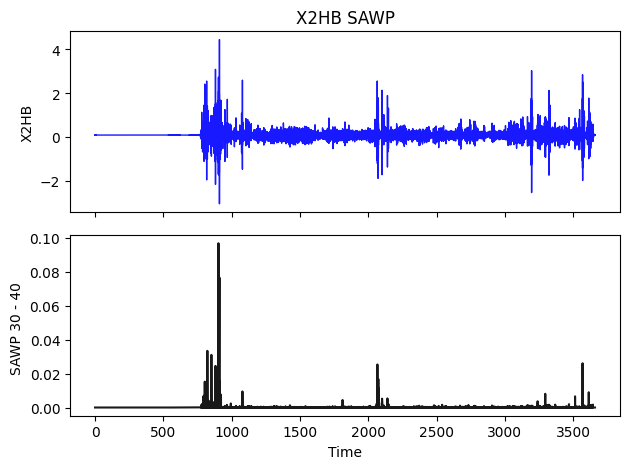

In [85]:
sawp(df_reduced, sensor="X2HB", wavelet="cmor1.5-1.0", fmin=30, fmax=40, sampling_sensor="Time", plot=True)

0.0009999660947396577
[33.33446355 33.14457277 32.95683317 32.7712084  32.58766294 32.40616203
 32.22667171 32.04915874 31.87359064 31.69993562 31.52816257 31.35824106
 31.19014133 31.02383423 30.85929123 30.69648442 30.53538646 30.37597058
 30.21821058 30.06208079 29.90755608 29.75461181 29.60322387 29.45336862
 29.3050229  29.15816401 29.01276972 28.86881823 28.72628816 28.58515856
 28.44540889 28.30701902 28.16996919 28.03424004 27.89981256 27.76666812
 27.63478843 27.50415557 27.37475193 27.24656024 27.11956356 26.99374526
 26.86908901 26.74557878 26.62319884 26.50193375 26.38176835 26.26268774
 26.14467729 26.02772266 25.91180972 25.79692463 25.68305378 25.57018378
 25.45830152 25.34739406 25.23744874 25.12845309 25.02039484 24.91326197
 24.80704264 24.70172521 24.59729824 24.49375048 24.39107089]


array([2.62672472e-09, 2.75328770e-09, 2.90362919e-09, ...,
       3.69309217e-10, 3.30406124e-10, 2.95102787e-10])

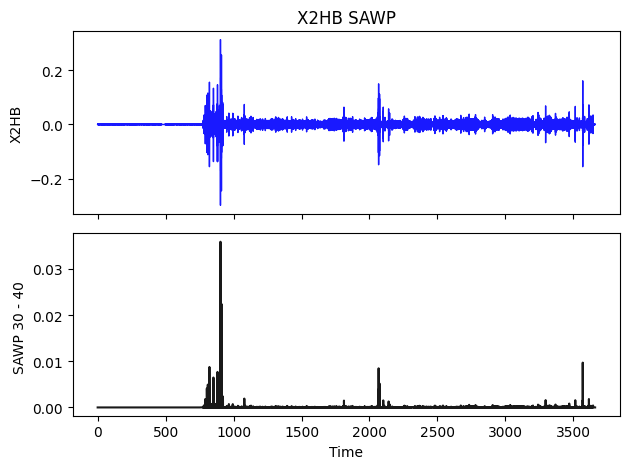

In [86]:
sawp(filt, sensor="X2HB", wavelet="cmor1.5-1.0", fmin=30, fmax=40, sampling_sensor="Time", plot=True)

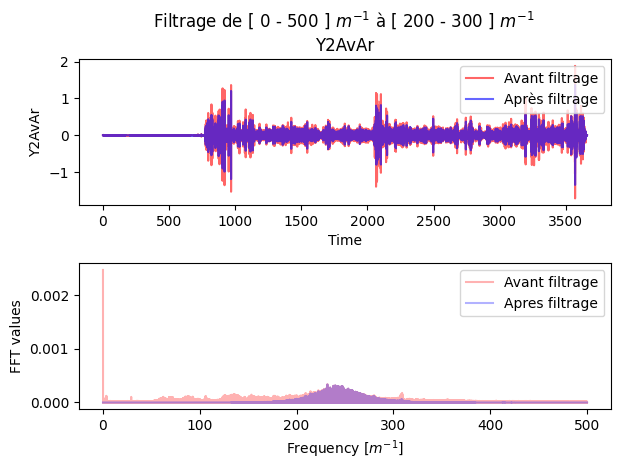

In [87]:
filt_y = band_pass_filter(df_reduced, ["Y2AvAr"], fmin=200, fmax=300, order=2, sampling_sensor="Time", plot=True)

0.0009999660947396577
[5.00016953 4.96102395 4.92248654 4.88454324 4.8471804  4.81038482
 4.77414367 4.73844451 4.70327528 4.66862426 4.63448009 4.60083172
 4.56766843 4.53497981 4.50275573 4.47098638 4.43966218 4.40877385
 4.37831236 4.3482689  4.31863495 4.28940219 4.26056251 4.23210805
 4.20403114 4.17632431 4.14898029 4.12199201 4.09535257 4.06905525
 4.04309349 4.01746093 3.99215132 3.96715862 3.9424769  3.9181004
 3.89402349 3.87024067 3.8467466  3.82353605 3.80060392 3.77794522
 3.7555551  3.73342881 3.7115617  3.68994927 3.66858707 3.64747079
 3.62659622 3.60595921 3.58555574 3.56538187 3.54543375 3.5257076
 3.50619974 3.48690657 3.46782456 3.44895026 3.43028031 3.4118114
 3.3935403  3.37546385 3.35757895 3.33988259 3.32237178]


array([3.95597656e-07, 4.90503512e-07, 5.75122987e-07, ...,
       1.85194288e-06, 2.33340047e-06, 2.47083819e-06])

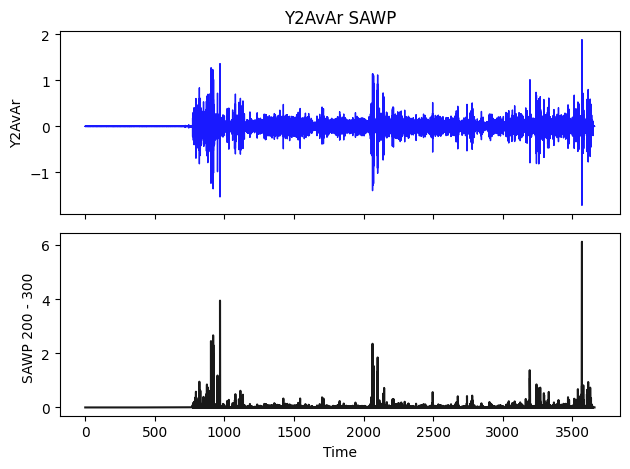

In [88]:
sawp(df_reduced, sensor="Y2AvAr", wavelet="cmor1.5-1.0", fmin=200, fmax=300, sampling_sensor="Time", plot=True)

0.0009999660947396577
[5.00016953 4.96102395 4.92248654 4.88454324 4.8471804  4.81038482
 4.77414367 4.73844451 4.70327528 4.66862426 4.63448009 4.60083172
 4.56766843 4.53497981 4.50275573 4.47098638 4.43966218 4.40877385
 4.37831236 4.3482689  4.31863495 4.28940219 4.26056251 4.23210805
 4.20403114 4.17632431 4.14898029 4.12199201 4.09535257 4.06905525
 4.04309349 4.01746093 3.99215132 3.96715862 3.9424769  3.9181004
 3.89402349 3.87024067 3.8467466  3.82353605 3.80060392 3.77794522
 3.7555551  3.73342881 3.7115617  3.68994927 3.66858707 3.64747079
 3.62659622 3.60595921 3.58555574 3.56538187 3.54543375 3.5257076
 3.50619974 3.48690657 3.46782456 3.44895026 3.43028031 3.4118114
 3.3935403  3.37546385 3.35757895 3.33988259 3.32237178]


array([2.02216122e-07, 2.80753909e-07, 3.57577398e-07, ...,
       8.96323195e-08, 9.07828976e-08, 8.29961896e-08])

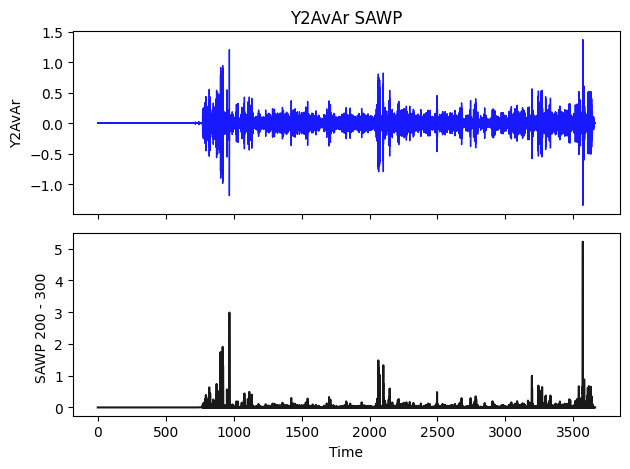

In [89]:
sawp(filt_y, sensor="Y2AvAr", wavelet="cmor1.5-1.0", fmin=200, fmax=300, sampling_sensor="Time", plot=True)

0.0009999660947396577
[5.00016953 4.96102395 4.92248654 4.88454324 4.8471804  4.81038482
 4.77414367 4.73844451 4.70327528 4.66862426 4.63448009 4.60083172
 4.56766843 4.53497981 4.50275573 4.47098638 4.43966218 4.40877385
 4.37831236 4.3482689  4.31863495 4.28940219 4.26056251 4.23210805
 4.20403114 4.17632431 4.14898029 4.12199201 4.09535257 4.06905525
 4.04309349 4.01746093 3.99215132 3.96715862 3.9424769  3.9181004
 3.89402349 3.87024067 3.8467466  3.82353605 3.80060392 3.77794522
 3.7555551  3.73342881 3.7115617  3.68994927 3.66858707 3.64747079
 3.62659622 3.60595921 3.58555574 3.56538187 3.54543375 3.5257076
 3.50619974 3.48690657 3.46782456 3.44895026 3.43028031 3.4118114
 3.3935403  3.37546385 3.35757895 3.33988259 3.32237178]


array([6.06358024e-07, 7.92495712e-07, 9.12023279e-07, ...,
       2.89286271e-07, 2.18086899e-07, 2.26762345e-07])

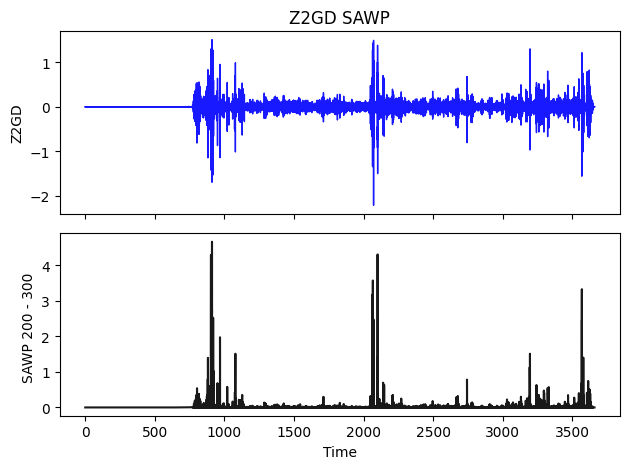

In [90]:
sawp(df_reduced, sensor="Z2GD", wavelet="cmor1.5-1.0", fmin=200, fmax=300, sampling_sensor="Time", plot=True)

(array([[ 8.17485724e-07+0.00000000e+00j, -5.28968940e-11+0.00000000e+00j,
          5.89083037e-11+0.00000000e+00j, ...,
          2.06167667e-10+0.00000000e+00j,  6.75602760e-07+0.00000000e+00j,
          8.31005734e-08+0.00000000e+00j],
        [-8.17535183e-07-7.97602037e-09j, -5.29416981e-11+1.58004730e-12j,
          5.88975187e-11+4.29355840e-13j, ...,
          2.06281635e-10+8.27485470e-13j, -4.99196627e-07+4.55642702e-07j,
          6.53859339e-08-5.12935823e-08j],
        [ 8.17485627e-07+1.59562744e-08j, -5.30674993e-11+3.18753145e-12j,
          5.90865530e-11+7.73719321e-13j, ...,
          2.06779752e-10+1.46866447e-12j,  6.12935594e-08-6.73250854e-07j,
          1.97822087e-08-8.07296394e-08j],
        ...,
        [ 8.17536822e-07-2.40323542e-08j,  3.69654471e-11-2.30058157e-12j,
         -4.53422960e-11-6.39361955e-13j, ...,
         -1.79801402e-10-2.16345984e-12j, -6.64440479e-08-6.73586585e-07j,
         -2.00684783e-08-7.97191391e-08j],
        [-8.17484182e-07+1.

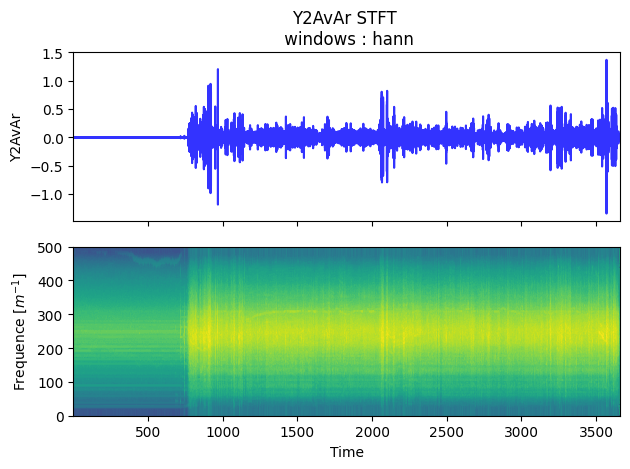

In [91]:
stft(
    filt_y,
    sensor="Y2AvAr",
    pkd=-1,
    pkf=-1,
    nperseg=512,
    nfft = 512,
    noverlap=int(0.5 * 500),
    window="hann",
    sampling_sensor="Time",
    log_plot = True,
    plot=True,
    get_axs = True,
)

(array([[ 1.33800125e-05-1.48999555e-05j,  9.58252874e-06+1.33528203e-06j,
          1.77723649e-05+2.07249263e-05j, ...,
          2.25976467e-05+1.39307645e-05j, -1.38137965e-05-6.83541001e-06j,
          6.00255711e-07-2.78725205e-05j],
        [-3.68172417e-06-2.37775496e-05j, -1.53623210e-05-2.86965861e-05j,
          3.89657386e-05+2.82472995e-05j, ...,
          3.24977241e-05-1.89340282e-05j,  1.43073155e-05+1.55095470e-05j,
          1.65877372e-07+5.45844844e-06j],
        [ 1.74400397e-05+2.12167303e-06j,  1.78709500e-05+5.95431459e-06j,
          1.40773545e-05+2.60093539e-06j, ...,
          3.47189968e-05+2.14538471e-05j, -4.03704426e-06-2.36189178e-05j,
          2.92508491e-07-2.98635582e-05j],
        ...,
        [ 9.14666652e-06-3.85316899e-08j,  1.02504827e-05+8.10430303e-06j,
          2.72222111e-05+2.03910608e-05j, ...,
          8.28509988e-06-9.25425143e-06j,  2.19166406e-05-5.96854269e-06j,
          7.28244236e-06-1.28357644e-05j],
        [ 1.56894086e-05-4.

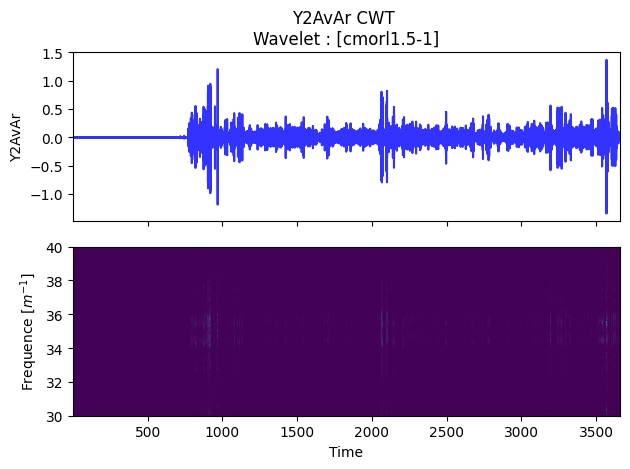

In [92]:
cwt( filt_y, sensor="Y2AvAr", pkd=-1, pkf=-1, wavelet="cmorl1.5-1",  fmin=30, fmax=40, sampling_sensor="Time",  plot=True, get_axs = True, )

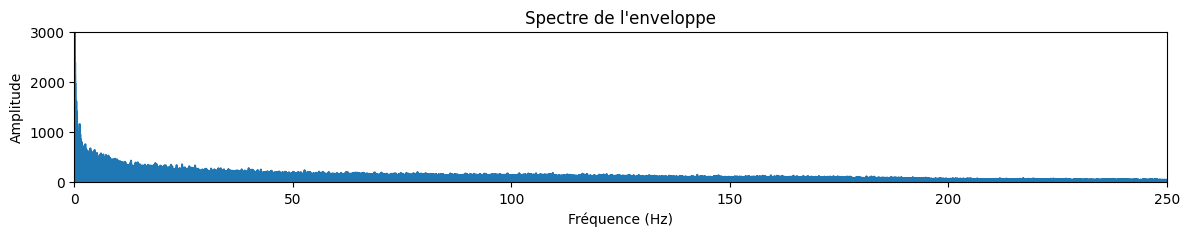

In [95]:
analytic_signal = hilbert(df_reduced['Y2AvAr'])
envelope = np.abs(analytic_signal)

fft_envelope = np.fft.fft(envelope)
freqs = np.fft.fftfreq(len(envelope), 1/fe)

plt.figure(figsize=(12, 6))

# Spectre de l'enveloppe
plt.subplot(3, 1, 3)
plt.plot(freqs[:len(freqs)//2], np.abs(fft_envelope[:len(freqs)//2]))
plt.title('Spectre de l\'enveloppe')
plt.xlabel('Fréquence (Hz)')
plt.ylabel('Amplitude')
plt.ylim(0, 3000)
plt.xlim(0, 250)  # Zoom sur les basses fréquences
plt.tight_layout()
plt.show()

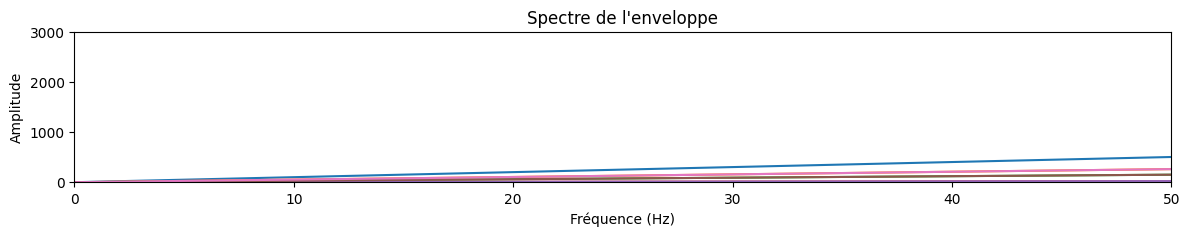

In [94]:
analytic_signal = hilbert(filt_y)
envelope = np.abs(analytic_signal)

fft_envelope = np.fft.fft(envelope)
freqs = np.fft.fftfreq(len(envelope), 1/fe)

plt.figure(figsize=(12, 6))

# Spectre de l'enveloppe
plt.subplot(3, 1, 3)
plt.plot(freqs[:len(freqs)//2], np.abs(fft_envelope[:len(freqs)//2]))
plt.title('Spectre de l\'enveloppe')
plt.xlabel('Fréquence (Hz)')
plt.ylabel('Amplitude')
plt.ylim(0, 3000)
plt.xlim(0, 50)  # Zoom sur les basses fréquences
plt.tight_layout()
plt.show()